
#IMPORT LIBRARIES


In [1]:
import tensorflow as tf
print("GPU:", tf.config.list_physical_devices('GPU'))
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.utils import plot_model
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


#Copy dataset from Drive → local runtime

#DATA PATH

In [3]:
import shutil, os, time

src = '/content/drive/MyDrive/facial expression classification'
dst = '/content/dataset'

if not os.path.exists(dst):
    print("Copying dataset from Drive to local disk (one-time, ~3-5 min)...")
    start = time.time()
    shutil.copytree(src, dst)
    print(f"✓ Done in {(time.time()-start)/60:.1f} min")
else:
    print("Dataset already copied locally")

# From here on, use the LOCAL path everywhere
dataset_path = '/content/dataset'
print(f"\nUsing dataset_path = {dataset_path}")


Copying dataset from Drive to local disk (one-time, ~3-5 min)...
✓ Done in 14.9 min

Using dataset_path = /content/dataset


#CLEAN DATASET

In [4]:
train_dir = '/content/dataset/train'
val_dir = '/content/dataset/validation'
test_dir = '/content/dataset/test'


train_gen = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(48, 48),
    batch_size=64,
    color_mode="grayscale"
)

val_gen = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(48, 48),
    batch_size=64,
    color_mode="grayscale"
)

Found 26921 files belonging to 7 classes.
Found 7066 files belonging to 7 classes.


In [ ]:
#NORMALIZE DATA

In [5]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_gen = train_gen.map(lambda x, y: (normalization_layer(x), y))
val_gen   = val_gen.map(lambda x, y: (normalization_layer(x), y))

#DATA ANALYSIS & VISUALIZATION

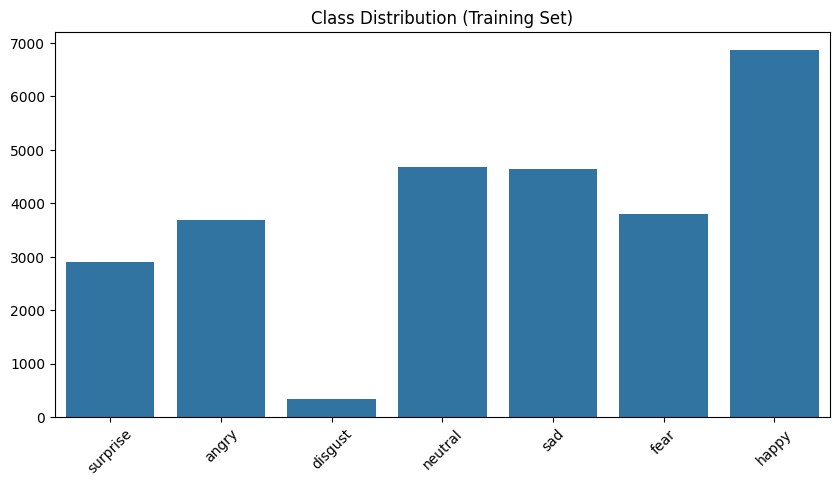

Classes found: ['surprise', 'angry', 'disgust', 'neutral', 'sad', 'fear', 'happy']


In [9]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# keep only folders (classes)
classes = [c for c in os.listdir(train_dir)
           if os.path.isdir(os.path.join(train_dir, c))]

counts = []

for c in classes:
    class_path = os.path.join(train_dir, c)
    counts.append(len(os.listdir(class_path)))

plt.figure(figsize=(10,5))
sns.barplot(x=classes, y=counts)
plt.title("Class Distribution (Training Set)")
plt.xticks(rotation=45)
plt.show()

print("Classes found:", classes)

#Sample Images

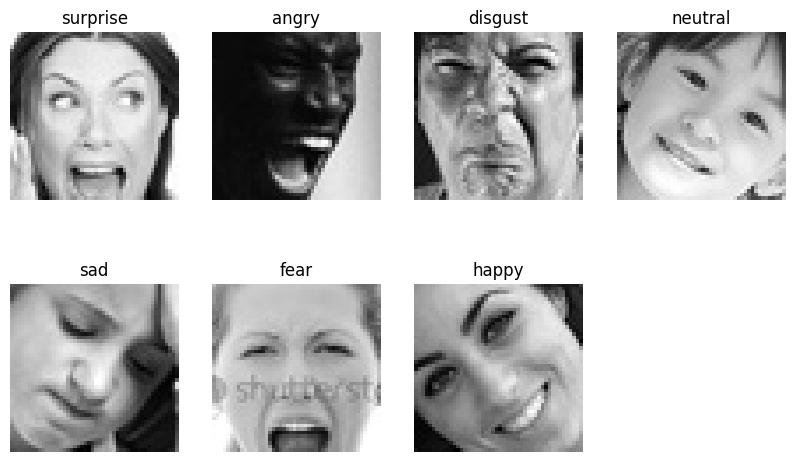

In [10]:
import cv2
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

plt.figure(figsize=(10,6))
for i, c in enumerate(classes):
    img_path = os.path.join(train_dir, c, os.listdir(os.path.join(train_dir, c))[0])
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    plt.subplot(2,4,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(c)
    plt.axis('off')

plt.show()

In [11]:
import os
from PIL import Image

def clean_corrupt_images(base_dirs):
    total_corrupt = 0

    for directory in base_dirs:
        print(f"\nScanning: {directory}")

        corrupt_files = []
        checked = 0

        for root, dirs, files in os.walk(directory):
            for file in files:
                path = os.path.join(root, file)
                checked += 1

                try:
                    with Image.open(path) as img:
                        img.verify()   # checks corruption
                except Exception:
                    print("Corrupt image found:", path)
                    corrupt_files.append(path)

        # delete corrupt images
        for f in corrupt_files:
            try:
                os.remove(f)
            except Exception as e:
                print("Could not delete:", f, "Reason:", e)

        print(f"Checked: {checked}")
        print(f"Removed: {len(corrupt_files)}")

        total_corrupt += len(corrupt_files)


    print(f"TOTAL CORRUPT IMAGES REMOVED: {total_corrupt}")


# Run for your dataset paths
clean_corrupt_images([train_dir, val_dir, test_dir])


Scanning: /content/dataset/train
Corrupt image found: /content/dataset/train/.DS_Store
Corrupt image found: /content/dataset/train/surprise/20587.jpg
Corrupt image found: /content/dataset/train/surprise/18532.jpg
Corrupt image found: /content/dataset/train/surprise/19774.jpg
Corrupt image found: /content/dataset/train/surprise/21366.jpg
Corrupt image found: /content/dataset/train/surprise/33242.jpg
Corrupt image found: /content/dataset/train/surprise/32170.jpg
Corrupt image found: /content/dataset/train/surprise/9703.jpg
Corrupt image found: /content/dataset/train/angry/26089.jpg
Corrupt image found: /content/dataset/train/angry/34380.jpg
Corrupt image found: /content/dataset/train/angry/8887.jpg
Corrupt image found: /content/dataset/train/angry/15395.jpg
Corrupt image found: /content/dataset/train/angry/6171.jpg
Corrupt image found: /content/dataset/train/angry/8149.jpg
Corrupt image found: /content/dataset/train/angry/18369.jpg
Corrupt image found: /content/dataset/train/disgust/971

In [17]:
import os
from PIL import Image

def remove_all_corrupt_images(base_dirs):
    total_removed = 0
    removed_files = []

    for directory in base_dirs:
        print(f"\nCleaning: {directory}")

        for root, dirs, files in os.walk(directory):
            for file in files:
                path = os.path.join(root, file)

                try:
                    # Try opening only image files safely
                    with Image.open(path) as img:
                        img.verify()

                except Exception:
                    # Remove anything invalid (images or wrong files like CSV)
                    try:
                        os.remove(path)
                        removed_files.append(path)
                        total_removed += 1
                        print("Removed:", path)
                    except Exception as e:
                        print("Could not remove:", path, "| Reason:", e)

    print("\n")
    print(f"TOTAL REMOVED CORRUPT FILES: {total_removed}")
    print("")

    return removed_files


removed_list = remove_all_corrupt_images([train_dir, val_dir, test_dir])


Cleaning: /content/dataset/train

Cleaning: /content/dataset/validation

Cleaning: /content/dataset/test


TOTAL REMOVED CORRUPT FILES: 0



#DATA PREPROCESSING + AUGMENTATION

In [18]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=False
)

Found 26872 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.


#CLASS WEIGHT (IMBALANCE HANDLING)

In [30]:
labels = train_gen.classes

classes = np.unique(labels)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=labels
)

class_weights = dict(zip(classes, class_weights))
print(class_weights)



{np.int32(0): np.float64(1.0414696535152315), np.int32(1): np.float64(11.668258792878854), np.int32(2): np.float64(1.0112900797832305), np.int32(3): np.float64(0.559844996770766), np.int32(4): np.float64(0.8211459129106188), np.int32(5): np.float64(0.8289477743159454), np.int32(6): np.float64(1.3246573991915607)}


#VISUALIZE AUGMENTATION

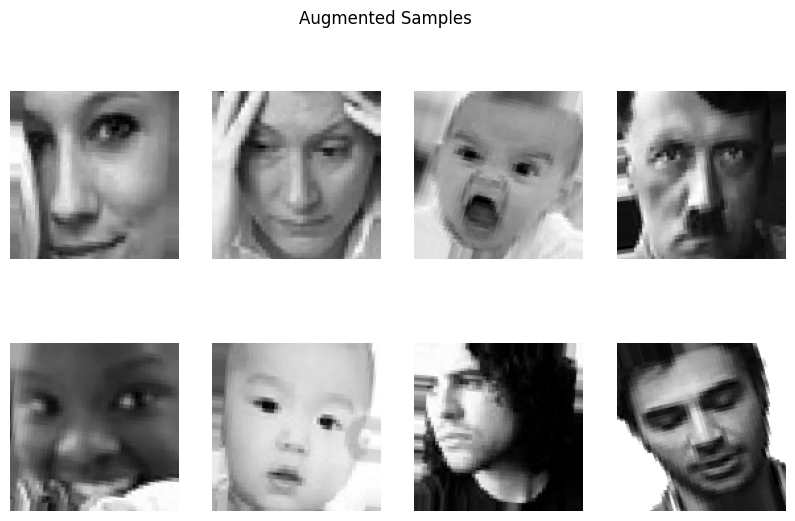

In [31]:
x_batch, y_batch = next(train_gen)

plt.figure(figsize=(10,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(x_batch[i].reshape(128,128), cmap='gray')
    plt.axis('off')

plt.suptitle("Augmented Samples")
plt.show()

##PART A — BASELINE MODEL

#BASELINE CNN

In [32]:
baseline_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),

    Dense(7, activation='softmax')
])

baseline_model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,557,063 (25.01 MB)

 Trainable params: 6,557,063 (25.01 MB)

 Non-trainable params: 0 (0.00 B)

#TRAIN BASELINE

In [33]:
history_base = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 80s 87ms/step - accuracy: 0.1934 - loss: 1.9027 - val_accuracy: 0.3106 - val_loss: 1.7814
Epoch 2/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 69s 82ms/step - accuracy: 0.2954 - loss: 1.7795 - val_accuracy: 0.3449 - val_loss: 1.6861
Epoch 3/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 68s 81ms/step - accuracy: 0.3531 - loss: 1.6526 - val_accuracy: 0.4118 - val_loss: 1.5441
Epoch 4/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 68s 81ms/step - accuracy: 0.3943 - loss: 1.5492 - val_accuracy: 0.4226 - val_loss: 1.5304
Epoch 5/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 67s 79ms/step - accuracy: 0.4163 - loss: 1.4915 - val_accuracy: 0.4363 - val_loss: 1.5029
Epoch 6/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 68s 81ms/step - accuracy: 0.4358 - loss: 1.4365 - val_accuracy: 0.4338 - val_loss: 1.4881
Epoch 7/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 67s 80ms/step - accuracy: 0.4470 - loss: 1.3959 - val_accuracy: 0.4523 - val_loss: 1.4130
Epoch 8/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 67s 80ms/step - accuracy: 0.4691 - loss: 1.3476 - 

#LOSS CURVE

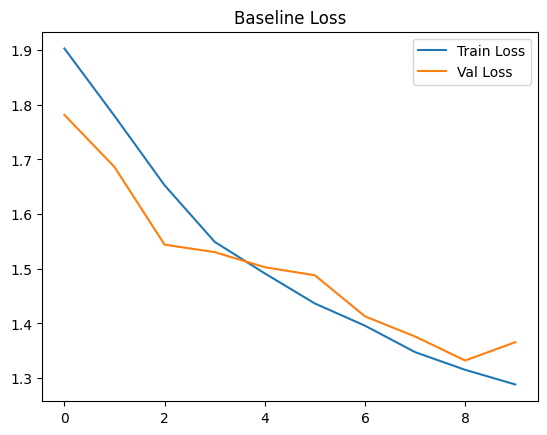

In [34]:
plt.plot(history_base.history['loss'], label='Train Loss')
plt.plot(history_base.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Baseline Loss")
plt.show()

#EVALUATION

In [35]:
preds = baseline_model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)

print(classification_report(test_gen.classes, y_pred))

60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
              precision    recall  f1-score   support

           0       0.34      0.40      0.37       300
           1       0.35      0.58      0.44       100
           2       0.36      0.21      0.27       300
           3       0.73      0.62      0.67       300
           4       0.45      0.49      0.47       300
           5       0.36      0.31      0.33       300
           6       0.63      0.75      0.69       300

    accuracy                           0.47      1900
   macro avg       0.46      0.48      0.46      1900
weighted avg       0.47      0.47      0.46      1900



#PART A — DEEPER MODEL + REGULARIZATION

#DEEP MODEL

In [36]:
deep_model = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(48,48,1)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(256,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),

    Dense(512,activation='relu'),
    Dropout(0.5),

    Dense(256,activation='relu'),
    Dropout(0.5),

    Dense(7,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#TRAIN WITH SGD

In [39]:
deep_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(7, activation='softmax')
])

In [41]:
from tensorflow.keras.optimizers import SGD

deep_model.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = deep_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    class_weight=class_weights
)

Epoch 1/25
840/840 ━━━━━━━━━━━━━━━━━━━━ 74s 85ms/step - accuracy: 0.4057 - loss: 1.5282 - val_accuracy: 0.3457 - val_loss: 1.6734
Epoch 2/25
840/840 ━━━━━━━━━━━━━━━━━━━━ 67s 80ms/step - accuracy: 0.4059 - loss: 1.5165 - val_accuracy: 0.4754 - val_loss: 1.3895
Epoch 3/25
840/840 ━━━━━━━━━━━━━━━━━━━━ 65s 78ms/step - accuracy: 0.3910 - loss: 1.5554 - val_accuracy: 0.4591 - val_loss: 1.4038
Epoch 4/25
840/840 ━━━━━━━━━━━━━━━━━━━━ 69s 82ms/step - accuracy: 0.3812 - loss: 1.5521 - val_accuracy: 0.4447 - val_loss: 1.4710
Epoch 5/25
840/840 ━━━━━━━━━━━━━━━━━━━━ 69s 82ms/step - accuracy: 0.3908 - loss: 1.5612 - val_accuracy: 0.4009 - val_loss: 1.5542
Epoch 6/25
840/840 ━━━━━━━━━━━━━━━━━━━━ 69s 82ms/step - accuracy: 0.4056 - loss: 1.5221 - val_accuracy: 0.4168 - val_loss: 1.5284
Epoch 7/25
840/840 ━━━━━━━━━━━━━━━━━━━━ 69s 82ms/step - accuracy: 0.4089 - loss: 1.5094 - val_accuracy: 0.4502 - val_loss: 1.4381
Epoch 8/25
840/840 ━━━━━━━━━━━━━━━━━━━━ 69s 82ms/step - accuracy: 0.3983 - loss: 1.5433 - 

#TRAIN WITH ADAM

In [42]:
deep_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_adam = deep_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    class_weight=class_weights
)

Epoch 1/25
840/840 ━━━━━━━━━━━━━━━━━━━━ 77s 87ms/step - accuracy: 0.3887 - loss: 1.6054 - val_accuracy: 0.4420 - val_loss: 1.4447
Epoch 2/25
840/840 ━━━━━━━━━━━━━━━━━━━━ 69s 82ms/step - accuracy: 0.4152 - loss: 1.5086 - val_accuracy: 0.4583 - val_loss: 1.4075
Epoch 3/25
840/840 ━━━━━━━━━━━━━━━━━━━━ 68s 81ms/step - accuracy: 0.4308 - loss: 1.4602 - val_accuracy: 0.4751 - val_loss: 1.3765
Epoch 4/25
840/840 ━━━━━━━━━━━━━━━━━━━━ 84s 83ms/step - accuracy: 0.4454 - loss: 1.4099 - val_accuracy: 0.4798 - val_loss: 1.3742
Epoch 5/25
840/840 ━━━━━━━━━━━━━━━━━━━━ 68s 81ms/step - accuracy: 0.4534 - loss: 1.3929 - val_accuracy: 0.4798 - val_loss: 1.3633
Epoch 6/25
840/840 ━━━━━━━━━━━━━━━━━━━━ 68s 81ms/step - accuracy: 0.4576 - loss: 1.3884 - val_accuracy: 0.4891 - val_loss: 1.3405
Epoch 7/25
840/840 ━━━━━━━━━━━━━━━━━━━━ 69s 82ms/step - accuracy: 0.4706 - loss: 1.3467 - val_accuracy: 0.4884 - val_loss: 1.3303
Epoch 8/25
840/840 ━━━━━━━━━━━━━━━━━━━━ 71s 84ms/step - accuracy: 0.4749 - loss: 1.3412 - 

#ABLATION STUDY (REMOVE DROPOUT)

In [44]:
ablation_model = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,1)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),
    Dense(256,activation='relu'),
    Dense(7,activation='softmax')
])

ablation_model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

ablation_model.fit(train_gen, validation_data=val_gen, epochs=15)

Epoch 1/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 76s 84ms/step - accuracy: 0.2699 - loss: 2.2724 - val_accuracy: 0.3036 - val_loss: 1.7465
Epoch 2/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 66s 79ms/step - accuracy: 0.3340 - loss: 1.6747 - val_accuracy: 0.3648 - val_loss: 1.6076
Epoch 3/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 68s 81ms/step - accuracy: 0.3705 - loss: 1.5805 - val_accuracy: 0.3977 - val_loss: 1.5704
Epoch 4/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 65s 77ms/step - accuracy: 0.3894 - loss: 1.5411 - val_accuracy: 0.3699 - val_loss: 1.5943
Epoch 5/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 67s 79ms/step - accuracy: 0.4100 - loss: 1.5017 - val_accuracy: 0.3481 - val_loss: 2.2000
Epoch 6/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 65s 78ms/step - accuracy: 0.4254 - loss: 1.4689 - val_accuracy: 0.2840 - val_loss: 1.8830
Epoch 7/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 69s 82ms/step - accuracy: 0.4322 - loss: 1.4535 - val_accuracy: 0.4362 - val_loss: 1.4579
Epoch 8/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 68s 80ms/step - accuracy: 0.4440 - loss: 1.4359 - 

#PART B — TRANSFER LEARNING (ResNet50)

In [45]:
train_gen_rgb = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen_rgb = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 26872 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.


#LOAD RESNET50

In [46]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


#CUSTOM HEAD

In [47]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(7, activation='softmax')(x)

model_resnet = Model(inputs=base_model.input, outputs=output)

#TRAIN (FEATURE EXTRACTION)

In [ ]:
model_resnet.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.fit(
    train_gen_rgb,
    validation_data=val_gen_rgb,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 447s 514ms/step - accuracy: 0.1146 - loss: 1.9588 - val_accuracy: 0.1728 - val_loss: 1.9436
Epoch 2/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 447s 532ms/step - accuracy: 0.0866 - loss: 1.9460 - val_accuracy: 0.1605 - val_loss: 1.9445
Epoch 3/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 422s 503ms/step - accuracy: 0.1591 - loss: 1.9448 - val_accuracy: 0.2522 - val_loss: 1.9398
Epoch 4/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 420s 500ms/step - accuracy: 0.2158 - loss: 1.9438 - val_accuracy: 0.2581 - val_loss: 1.9441
Epoch 5/10
375/840 ━━━━━━━━━━━━━━━━━━━━ 3:41 476ms/step - accuracy: 0.0715 - loss: 1.9396

#FINE-TUNING

In [ ]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

model_resnet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.fit(
    train_gen_rgb,
    validation_data=val_gen_rgb,
    epochs=10,
    class_weight=class_weights
)

#FINAL EVALUATION

In [ ]:
preds = model_resnet.predict(test_gen)
y_pred = np.argmax(preds, axis=1)

print(classification_report(test_gen.classes, y_pred))